In [47]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [48]:
condition = "3mod_s126_sd"
n_samples_test = 100
split = "test"
dataset = "form_50_35_15_cgc_3_20"

def get_saved_epochs(root_path, project_name, experiment_name):
    pattern = f"{root_path}/checkpoints/{project_name}/{experiment_name}/checkpoints/save-epoch=*.ckpt"
    paths = glob.glob(pattern)
    epochs = []
    for p in paths:
        match = re.search(r'save-epoch=(\d+)\.ckpt', p)
        if match:
            epochs.append(int(match.group(1)))
    return sorted(epochs)

experiment_name = get_experiment_name(condition, dataset, 0)
saved_epochs = get_saved_epochs(root_path, "syn", experiment_name)

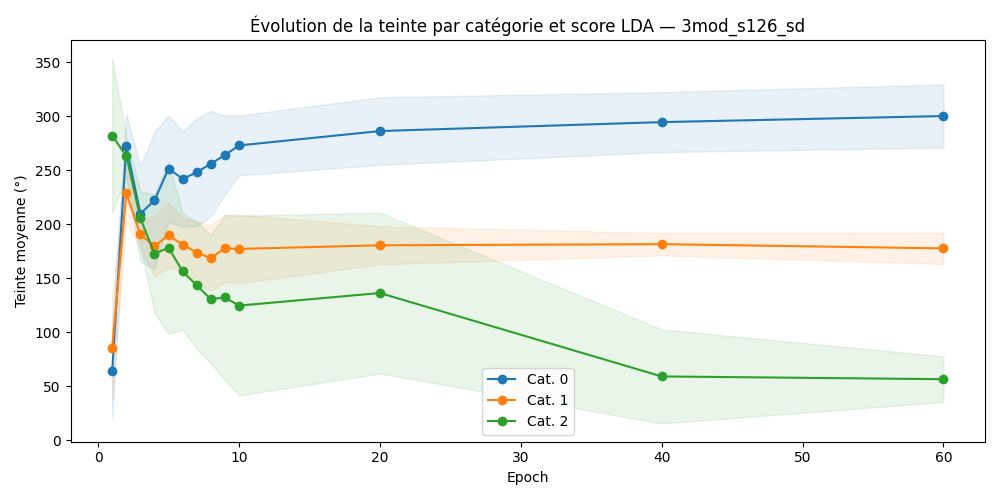

In [50]:
import matplotlib.pyplot as plt
import numpy as np

epochs = saved_epochs[0:13]
results_per_epoch = {}

for checkpoint_epoch in epochs:
    with total_silence():
        global_workspace, domain_mods, gw_mod, visual_module, original_data, latent_domains, modules_name = \
            get_modules_data_from_exp(
                experiment_name=experiment_name,
                n_samples_test=n_samples_test,
                split=split,
                checkpoint_epoch=checkpoint_epoch
            )
        objects = get_objects_from_v_latents(
            latent_domains, gw_mod, global_workspace, modules_name, start_v=False
        )

    cat = []
    if 'attr' in modules_name:
        cat = original_data['attr'][0]
    if 'cat' in modules_name:
        cat = original_data['cat']

    colors_np = objects['x2']['color'].detach().cpu().numpy()
    cats = cat.argmax(dim=1).detach().cpu().numpy()

    metrics, _ = hue_analysis(colors_np, cats, cat_names=CAT_NAMES, value=0.75, saturation_boost=1.8)
    results_per_epoch[checkpoint_epoch] = metrics

# --- Extraction des données ---
cat_ids = list(results_per_epoch[1]['per_cat'].keys())
cat_names = [results_per_epoch[1]['per_cat'][c]['name'] for c in cat_ids]
lda_scores = [results_per_epoch[e]['lda_score'] for e in epochs]
mean_hues = {
    c: [results_per_epoch[e]['per_cat'][c]['mean_hue'] for e in epochs]
    for c in cat_ids
}

# --- Graphique ---
fig, ax1 = plt.subplots(figsize=(10, 5))

colors = plt.cm.tab10.colors
for i, (cat_id, name) in enumerate(zip(cat_ids, cat_names)):
    ax1.plot(list(epochs), mean_hues[cat_id], marker='o', label=name, color=colors[i])
    # Optionnel : afficher std comme zone ombrée
    std_hues = [results_per_epoch[e]['per_cat'][cat_id]['std_hue'] for e in epochs]
    ax1.fill_between(
        list(epochs),
        [m - s for m, s in zip(mean_hues[cat_id], std_hues)],
        [m + s for m, s in zip(mean_hues[cat_id], std_hues)],
        alpha=0.1, color=colors[i]
    )


ax1.set_xlabel('Epoch')
ax1.set_ylabel('Teinte moyenne (°)')

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1 , labels1 , loc='best')

ax1.set_title(f'Évolution de la teinte par catégorie et score LDA — {condition}')
plt.tight_layout()
plt.show()